# DSAI 490 — Assignment 1
## Representation Learning with Autoencoders (AE & VAE)
---

## 1. Imports & Setup

In [1]:
import os, warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [2]:
DATA_PATH         = '/content/drive/MyDrive/medical-mnist'
CLASS_NAMES       = ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']
IMG_SIZE          = (64, 64)
INPUT_SHAPE       = (64, 64, 1)
LATENT_DIM        = 16
BATCH_SIZE        = 32
EPOCHS            = 20
SAMPLES_PER_CLASS = 200
NOISE_FACTOR      = 0.35

## 3. Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(DATA_PATH, cls)))
    print(f'  {cls:12s} -> {n} images')

Mounted at /content/drive
  AbdomenCT    -> 10000 images
  BreastMRI    -> 8954 images
  ChestCT      -> 10000 images
  CXR          -> 10002 images
  Hand         -> 2560 images
  HeadCT       -> 10000 images


## 4. Load Data (Sample)

In [5]:
def load_images(data_path, class_names, n_per_class):
    images, labels = [], []
    for i, cls in enumerate(class_names):
        folder = os.path.join(data_path, cls)
        files  = sorted(os.listdir(folder))[:n_per_class]
        for f in files:
            raw = tf.io.read_file(os.path.join(folder, f))
            img = tf.image.decode_jpeg(raw, channels=1)
            img = tf.image.resize(img, IMG_SIZE)
            img = tf.cast(img, tf.float32) / 255.0
            images.append(img.numpy())
            labels.append(i)
    return np.array(images, dtype='float32'), np.array(labels)

X, y = load_images(DATA_PATH, CLASS_NAMES, SAMPLES_PER_CLASS)

idx  = np.random.permutation(len(X))
X, y = X[idx], y[idx]

split     = int(0.85 * len(X))
X_train   = X[:split];  X_val = X[split:]
y_train   = y[:split];  y_val = y[split:]

print(f'Train: {X_train.shape}   Val: {X_val.shape}')

Train: (1020, 64, 64, 1)   Val: (180, 64, 64, 1)


## 5. Build tf.data Pipelines

In [6]:
def make_dataset(X, shuffle=True, noisy=False):
    ds = tf.data.Dataset.from_tensor_slices((X, X))
    if shuffle:
        ds = ds.shuffle(len(X), seed=42)
    if noisy:
        def add_noise(x, y):
            n = tf.random.normal(tf.shape(x), stddev=NOISE_FACTOR)
            return tf.clip_by_value(x + n, 0, 1), y
        ds = ds.map(add_noise)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds       = make_dataset(X_train)
val_ds         = make_dataset(X_val, shuffle=False)
train_ds_noisy = make_dataset(X_train, noisy=True)
val_ds_noisy   = make_dataset(X_val, shuffle=False, noisy=True)

print('Pipelines ready.')

Pipelines ready.


## 6. Sample Images per Class

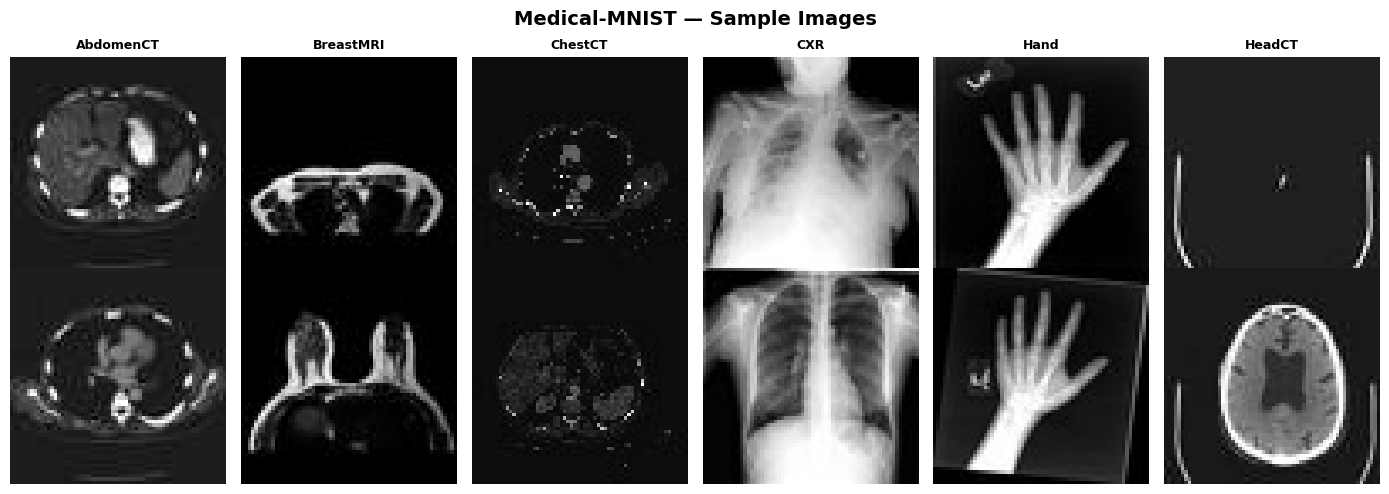

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Medical-MNIST — Sample Images', fontsize=14, fontweight='bold')

for col, cls in enumerate(CLASS_NAMES):
    mask = y == col
    for row in range(2):
        ax = axes[row, col]
        ax.imshow(X[mask][row].squeeze(), cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(cls, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Model Architectures (Encoder & Decoder)

In [8]:
def build_encoder(latent_dim, name='encoder'):
    inp = layers.Input(INPUT_SHAPE)
    x   = layers.Conv2D(32,  3, strides=2, padding='same', activation='relu')(inp)
    x   = layers.Conv2D(64,  3, strides=2, padding='same', activation='relu')(x)
    x   = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(128, activation='relu')(x)
    z   = layers.Dense(latent_dim)(x)
    return Model(inp, z, name=name)

def build_decoder(latent_dim, name='decoder'):
    inp = layers.Input((latent_dim,))
    x   = layers.Dense(8 * 8 * 128, activation='relu')(inp)
    x   = layers.Reshape((8, 8, 128))(x)
    x   = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x   = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    x   = layers.Conv2DTranspose(1,  3, strides=2, padding='same', activation='sigmoid')(x)
    return Model(inp, x, name=name)

print('Encoder:', build_encoder(LATENT_DIM).count_params(), 'params')
print('Decoder:', build_decoder(LATENT_DIM).count_params(), 'params')

Encoder: 1143440 params
Decoder: 231809 params


## 8. Autoencoder Model

In [9]:
class Autoencoder(Model):
    def __init__(self):
        super().__init__()
        self.encoder = build_encoder(LATENT_DIM, 'ae_encoder')
        self.decoder = build_decoder(LATENT_DIM, 'ae_decoder')

    def call(self, x, training=False):
        return self.decoder(self.encoder(x, training=training), training=training)

    def encode(self, x):
        return self.encoder(x, training=False)

ae = Autoencoder()
ae.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
ae.encoder.summary()

Model: "ae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,440 (4.36 MB)

 Trainable params: 1,143,440 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Train AE

In [10]:
ae_history = ae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[EarlyStopping('val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - loss: 0.0840 - val_loss: 0.0519
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0389 - val_loss: 0.0361
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0283 - val_loss: 0.0265
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0226 - val_loss: 0.0227
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0199 - val_loss: 0.0209
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0179 - val_loss: 0.0192
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0161 - val_loss: 0.0177
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0150 - val_loss: 0.0167
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0141 - val_loss: 0.0162
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0136 - val_loss: 0.0153
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0129 - val_loss: 0.0150
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0123 - val

## 10. VAE Model

In [14]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * epsilon

In [15]:
class VAE(Model):
    def __init__(self):
        super().__init__()
        inp = layers.Input(INPUT_SHAPE)
        x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inp)
        x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.Flatten()(x)
        x = layers.Dense(128, activation='relu')(x)
        mu = layers.Dense(LATENT_DIM)(x)
        log_var = layers.Dense(LATENT_DIM)(x)
        z = Sampling()([mu, log_var])
        self.encoder = Model(inp, [mu, log_var, z], name='vae_encoder')
        self.decoder = build_decoder(LATENT_DIM, 'vae_decoder')
        self.t = tf.keras.metrics.Mean(name='loss')
        self.r = tf.keras.metrics.Mean(name='recon')
        self.kl = tf.keras.metrics.Mean(name='kl')

    @property
    def metrics(self):
        return [self.t, self.r, self.kl]

    def call(self, x, training=False):
        mu, _, z = self.encoder(x, training=training)
        return self.decoder(z, training=training)

    def encode(self, x):
        mu, _, _ = self.encoder(x, training=False)
        return mu

    def generate(self, n):
        return self.decoder(tf.random.normal((n, LATENT_DIM)), training=False)

    def compute_losses(self, x, training):
        mu, lv, z = self.encoder(x, training=training)
        xh = self.decoder(z, training=training)
        r  = tf.reduce_mean(tf.reduce_sum(tf.square(x - xh), axis=[1,2,3]))
        kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + lv - tf.square(mu) - tf.exp(lv), axis=1))
        return r + kl, r, kl

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            total, r, kl = self.compute_losses(x, True)
        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.t.update_state(total)
        self.r.update_state(r)
        self.kl.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, _ = data
        total, r, kl = self.compute_losses(x, False)
        self.t.update_state(total)
        self.r.update_state(r)
        self.kl.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

## 11. Train VAE

In [16]:
vae = VAE()

vae.compile(
    optimizer=optimizers.Adam(1e-3)
)

vae_history = vae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[EarlyStopping('val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - kl: 7.6599 - loss: 315.2806 - recon: 307.6206 - val_kl: 17.6609 - val_loss: 218.2525 - val_recon: 200.5916
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl: 9.1038 - loss: 179.0180 - recon: 169.9143 - val_kl: 7.4430 - val_loss: 179.7527 - val_recon: 172.3097
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl: 7.5127 - loss: 160.9455 - recon: 153.4328 - val_kl: 8.2287 - val_loss: 171.2646 - val_recon: 163.0359
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - kl: 7.4665 - loss: 153.9496 - recon: 146.4831 - val_kl: 9.5284 - val_loss: 165.2151 - val_recon: 155.6867
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl: 8.2440 - loss: 147.5282 - recon: 139.2843 - val_kl: 9.4131 - val_loss: 157.3538 - val_recon: 147.9407
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl: 8.6743 - loss: 141.5798 - recon: 132.9054 - val_kl: 9.3064 - val_loss: 151.6364 - val_recon: 142.3300
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

## 12. Loss Curves — AE & VAE

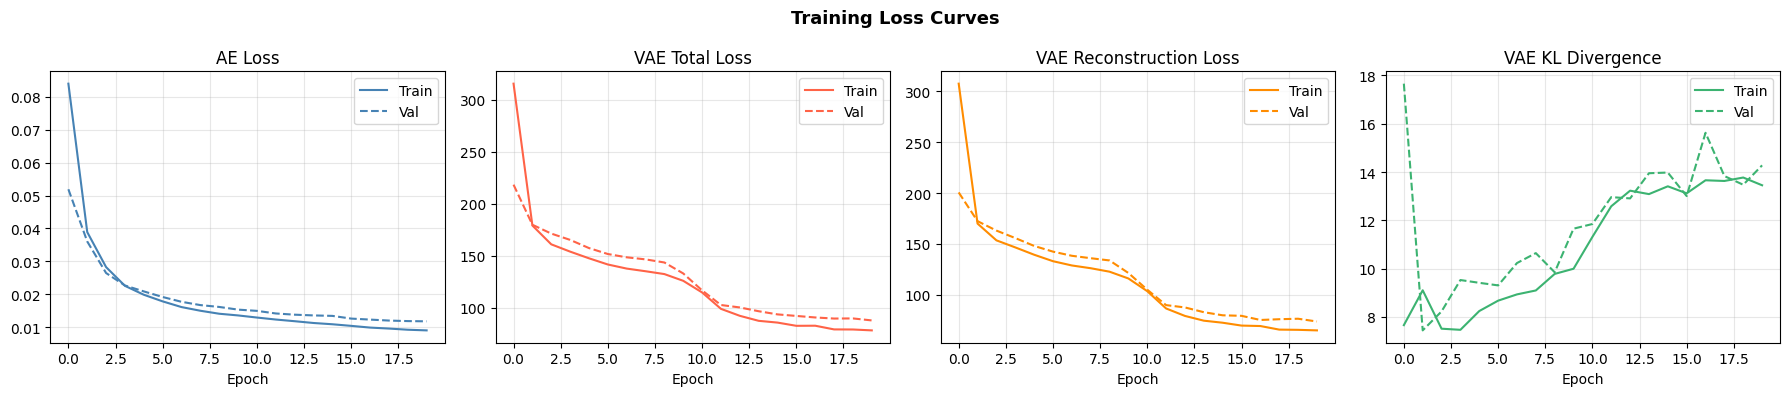

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Training Loss Curves', fontsize=13, fontweight='bold')

axes[0].plot(ae_history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(ae_history.history['val_loss'], label='Val',   color='steelblue', ls='--')
axes[0].set_title('AE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(vae_history.history['loss'],     label='Train', color='tomato')
axes[1].plot(vae_history.history['val_loss'], label='Val',   color='tomato', ls='--')
axes[1].set_title('VAE Total Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(vae_history.history['recon'],     label='Train', color='darkorange')
axes[2].plot(vae_history.history['val_recon'], label='Val',   color='darkorange', ls='--')
axes[2].set_title('VAE Reconstruction Loss'); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(vae_history.history['kl'],     label='Train', color='mediumseagreen')
axes[3].plot(vae_history.history['val_kl'], label='Val',   color='mediumseagreen', ls='--')
axes[3].set_title('VAE KL Divergence'); axes[3].legend(); axes[3].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## 13. AE — Reconstructions

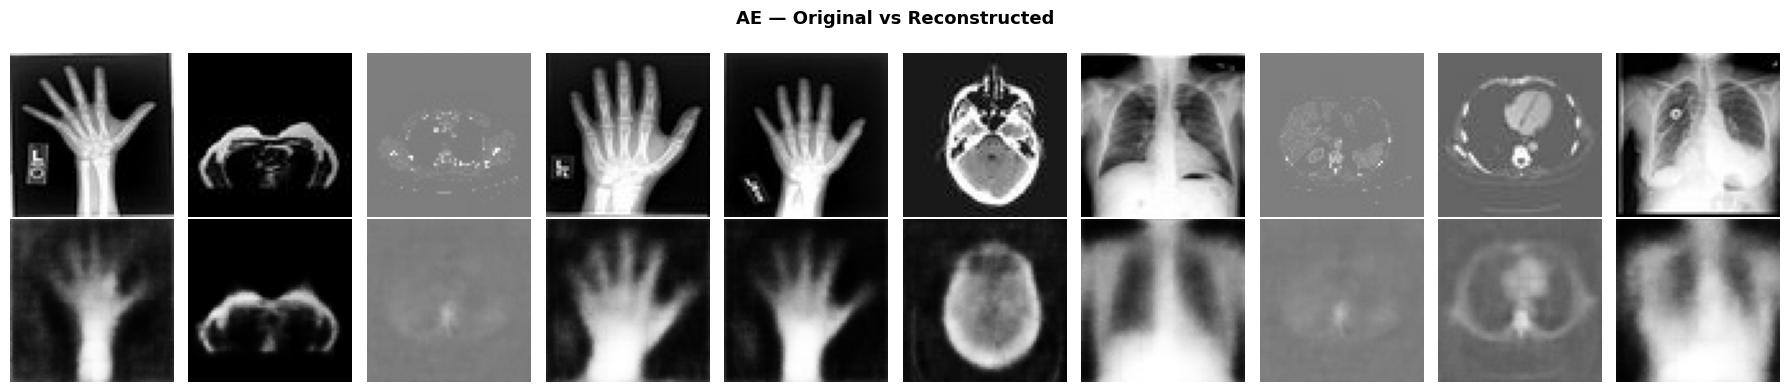

In [18]:
n     = 10
imgs  = X_val[:n]
recon = ae(imgs, training=False).numpy()

fig, axes = plt.subplots(2, n, figsize=(18, 4))
fig.suptitle('AE — Original vs Reconstructed', fontsize=13, fontweight='bold')

for i in range(n):
    axes[0, i].imshow(imgs[i].squeeze(),  cmap='gray', vmin=0, vmax=1); axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].squeeze(), cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original',      fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
plt.tight_layout()
plt.show()

## 14. VAE — Reconstructions

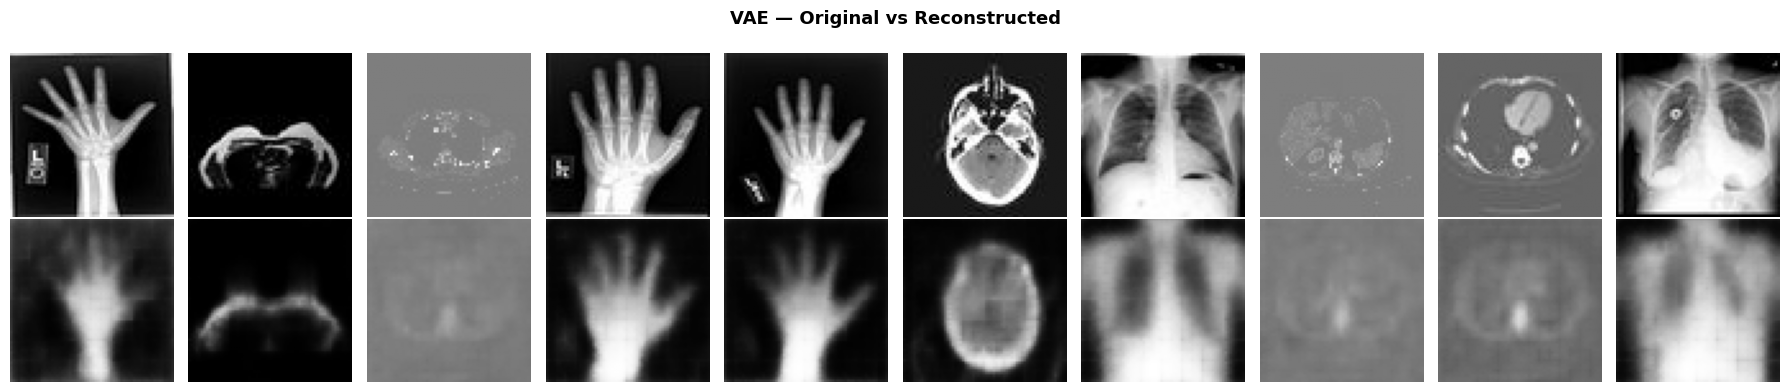

In [19]:
recon_vae = vae(imgs, training=False).numpy()

fig, axes = plt.subplots(2, n, figsize=(18, 4))
fig.suptitle('VAE — Original vs Reconstructed', fontsize=13, fontweight='bold')

for i in range(n):
    axes[0, i].imshow(imgs[i].squeeze(),      cmap='gray', vmin=0, vmax=1); axes[0, i].axis('off')
    axes[1, i].imshow(recon_vae[i].squeeze(), cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original',      fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
plt.tight_layout()
plt.show()

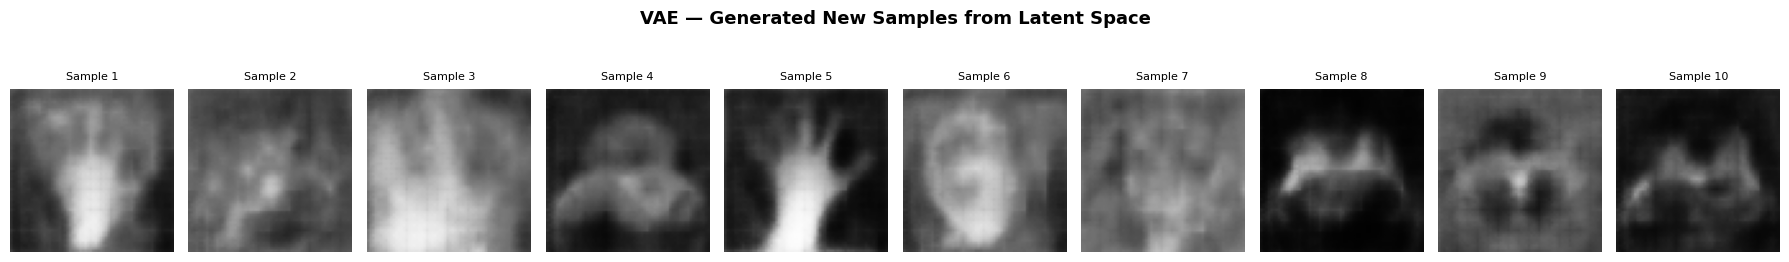

In [26]:
# 14.5 VAE — Generation of New Samples

n_generate = 10
generated_images = vae.generate(n_generate).numpy()

fig, axes = plt.subplots(1, n_generate, figsize=(18, 3))
fig.suptitle('VAE — Generated New Samples from Latent Space', fontsize=13, fontweight='bold')

for i in range(n_generate):
    axes[i].imshow(generated_images[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    axes[i].set_title(f'Sample {i+1}', fontsize=8)

plt.tight_layout()
plt.show()

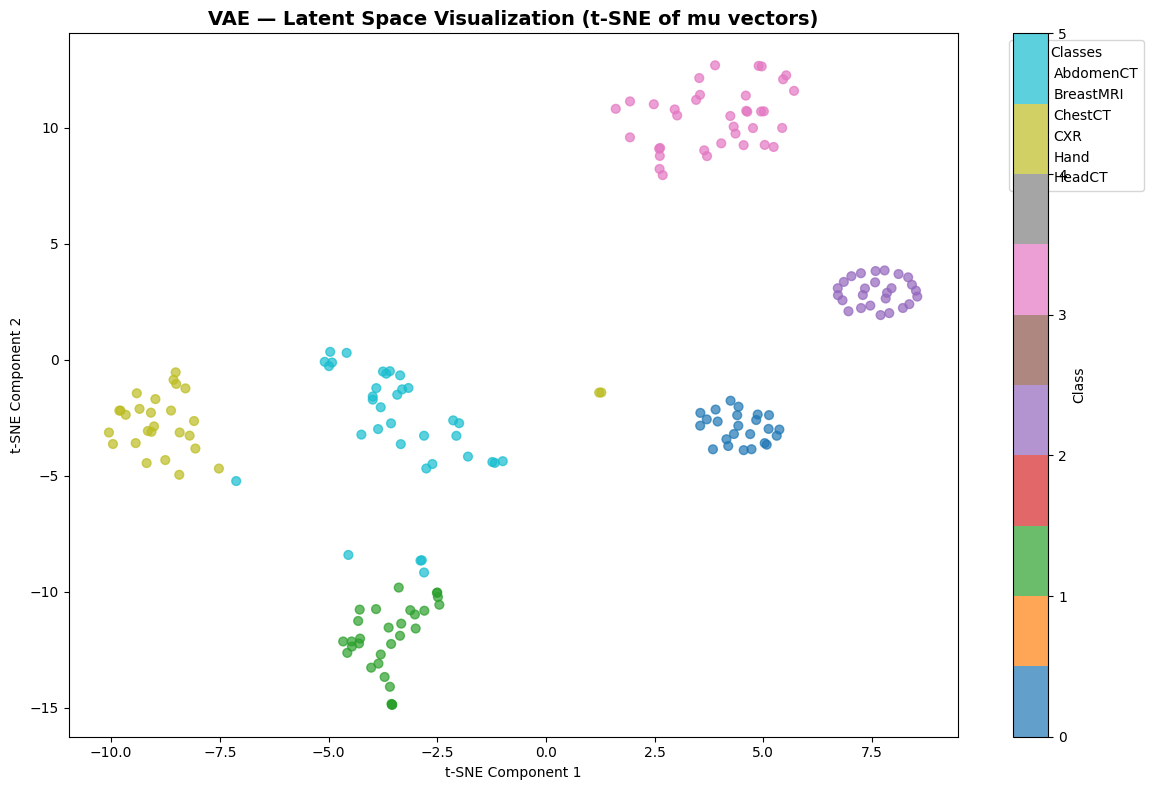

In [27]:
# 14.6 VAE — Latent Space Visualization (t-SNE)

mu_vectors = vae.encode(X_val).numpy()

tsne_vae = TSNE(n_components=2, random_state=42, perplexity=30)
mu_2d_vae = tsne_vae.fit_transform(mu_vectors)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(mu_2d_vae[:, 0], mu_2d_vae[:, 1], c=y_val, cmap='tab10', alpha=0.7, s=40)
plt.colorbar(scatter, ticks=range(len(CLASS_NAMES)), label='Class')
plt.title('VAE — Latent Space Visualization (t-SNE of mu vectors)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab10(i/10), markersize=8)
           for i in range(len(CLASS_NAMES))]
plt.legend(handles, CLASS_NAMES, title='Classes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 15. Denoising AE

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 0.0876 - val_loss: 0.0693
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0451 - val_loss: 0.0439
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0369 - val_loss: 0.0377
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0287 - val_loss: 0.0271
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0234 - val_loss: 0.0243
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0210 - val_loss: 0.0221
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0187 - val_loss: 0.0198
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0171 - val_loss: 0.0187
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0160 - val_loss: 0.0176
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0151 - val_loss: 0.0169
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0144 - val_loss: 0.0165
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.013

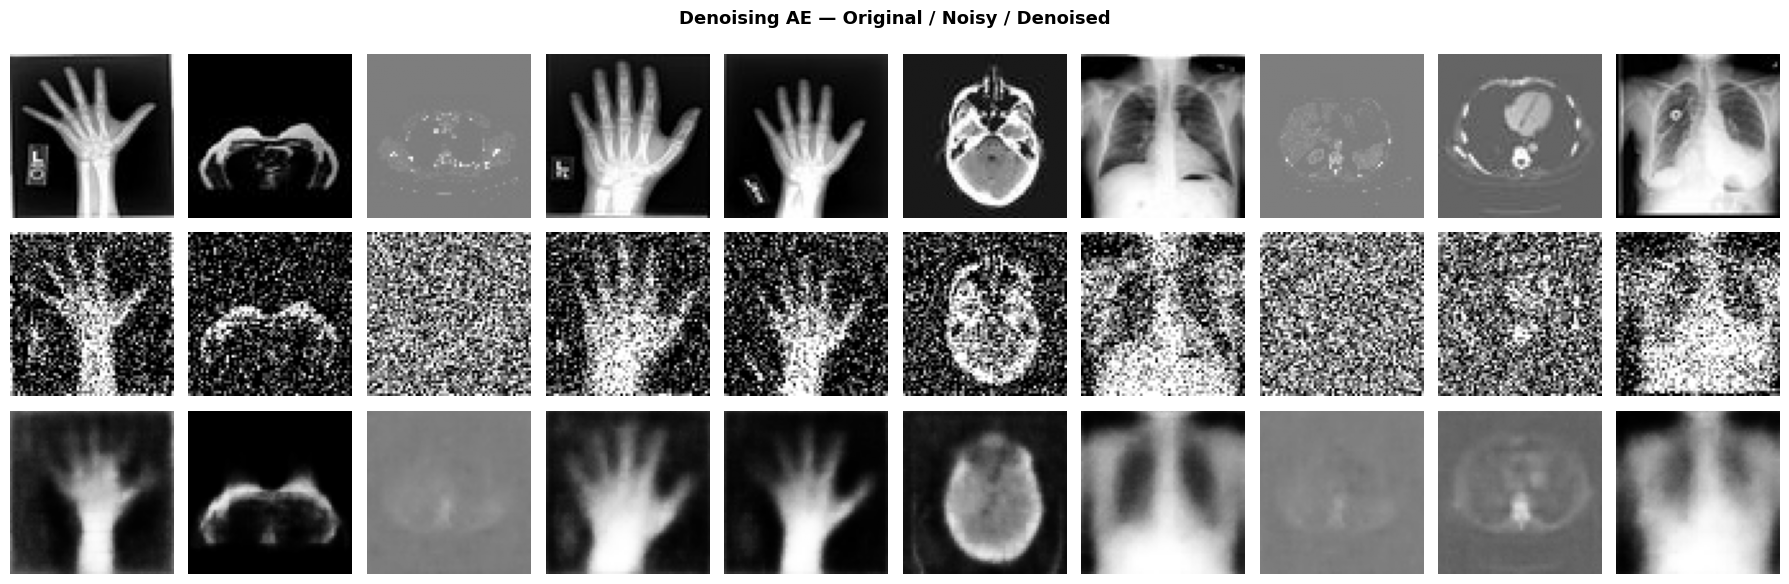

In [20]:
dae = Autoencoder()
dae.compile(optimizer=optimizers.Adam(1e-3), loss='mse')

dae.fit(
    train_ds_noisy,
    validation_data=val_ds_noisy,
    epochs=EPOCHS,
    callbacks=[EarlyStopping('val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

noise      = np.random.normal(0, NOISE_FACTOR, imgs.shape).astype('float32')
noisy_imgs = np.clip(imgs + noise, 0, 1)
denoised   = dae(noisy_imgs, training=False).numpy()

fig, axes = plt.subplots(3, n, figsize=(18, 6))
fig.suptitle('Denoising AE — Original / Noisy / Denoised', fontsize=13, fontweight='bold')

for i in range(n):
    axes[0, i].imshow(imgs[i].squeeze(),       cmap='gray', vmin=0, vmax=1); axes[0, i].axis('off')
    axes[1, i].imshow(noisy_imgs[i].squeeze(), cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')
    axes[2, i].imshow(denoised[i].squeeze(),   cmap='gray', vmin=0, vmax=1); axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Noisy',    fontsize=9)
axes[2, 0].set_ylabel('Denoised', fontsize=9)
plt.tight_layout()
plt.show()

## 16. Latent Space — t-SNE (AE vs VAE)

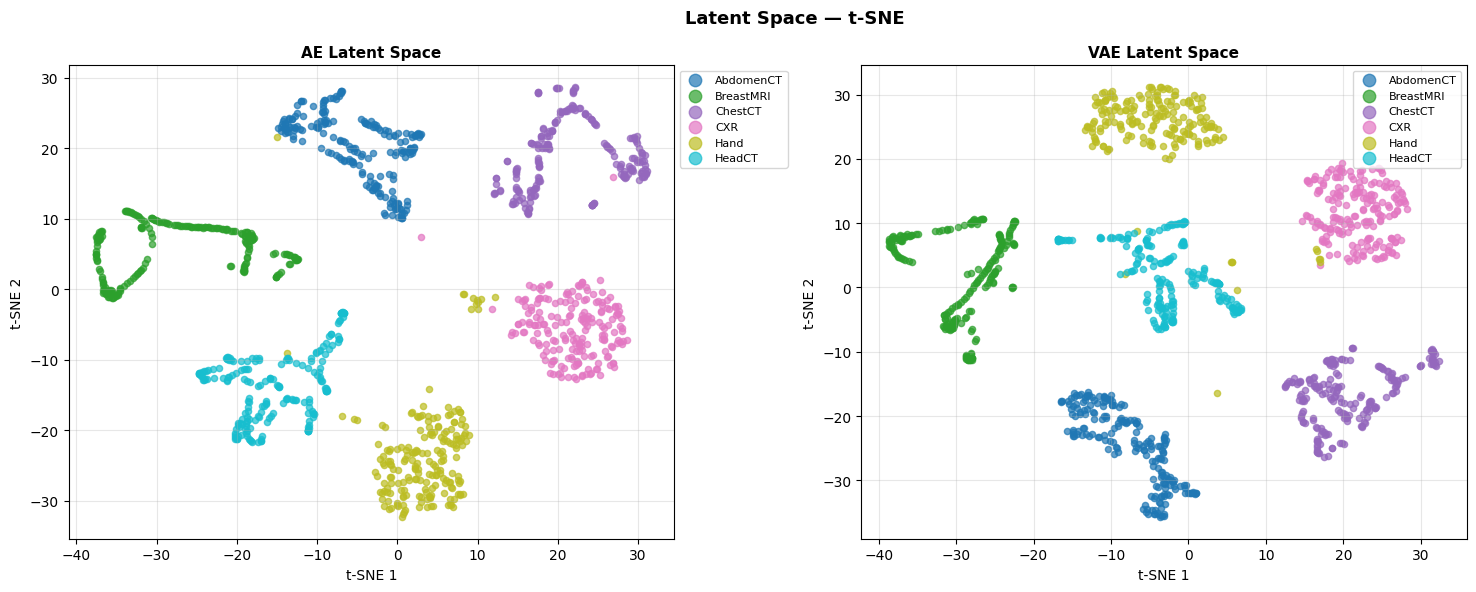

In [21]:
z_ae  = ae.encode(X).numpy()
z_vae = vae.encode(X).numpy()

ae_2d  = TSNE(2, random_state=42, perplexity=30, n_iter=500).fit_transform(z_ae)
vae_2d = TSNE(2, random_state=42, perplexity=30, n_iter=500).fit_transform(z_vae)

colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Latent Space — t-SNE', fontsize=13, fontweight='bold')

for ax, z2d, title in zip(axes, [ae_2d, vae_2d], ['AE', 'VAE']):
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
        m = y == i
        ax.scatter(z2d[m, 0], z2d[m, 1], color=col, label=cls, alpha=0.7, s=20)
    ax.set_title(f'{title} Latent Space', fontsize=11, fontweight='bold')
    ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1, 1))
    ax.grid(alpha=0.3)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

## 17. VAE — Generate New Images

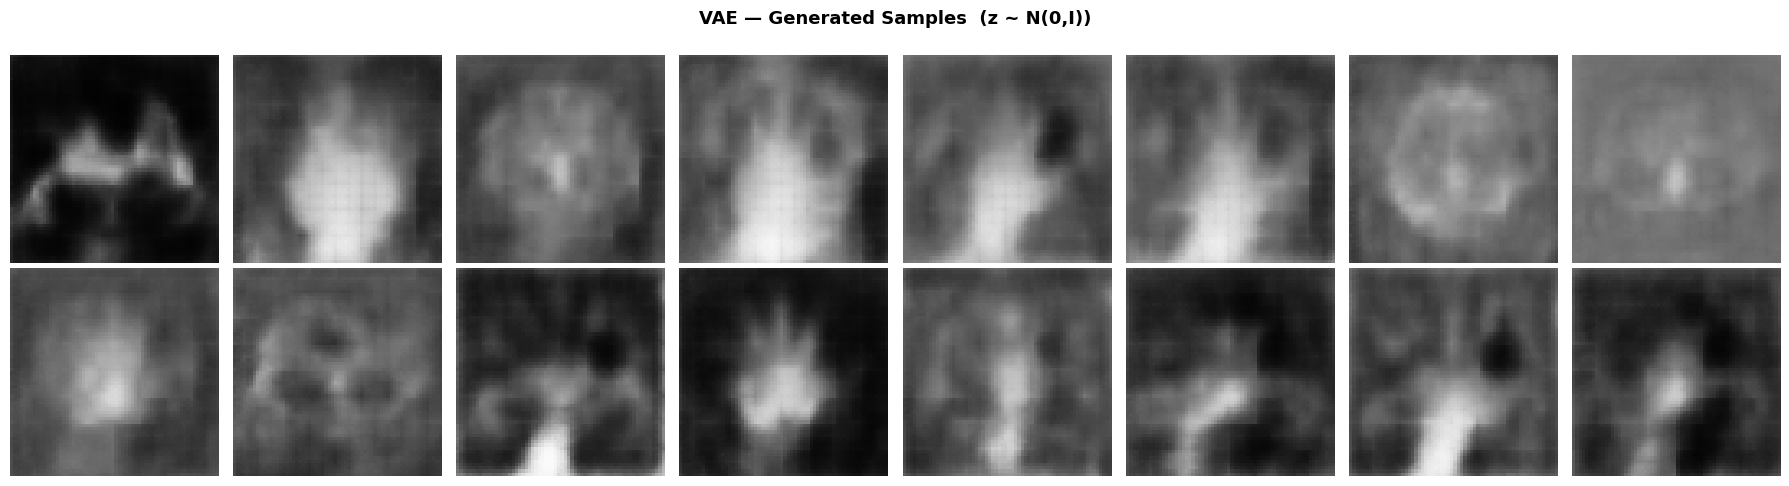

In [22]:
generated = vae.generate(16).numpy()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('VAE — Generated Samples  (z ~ N(0,I))', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 18. VAE — Latent Space Traversal

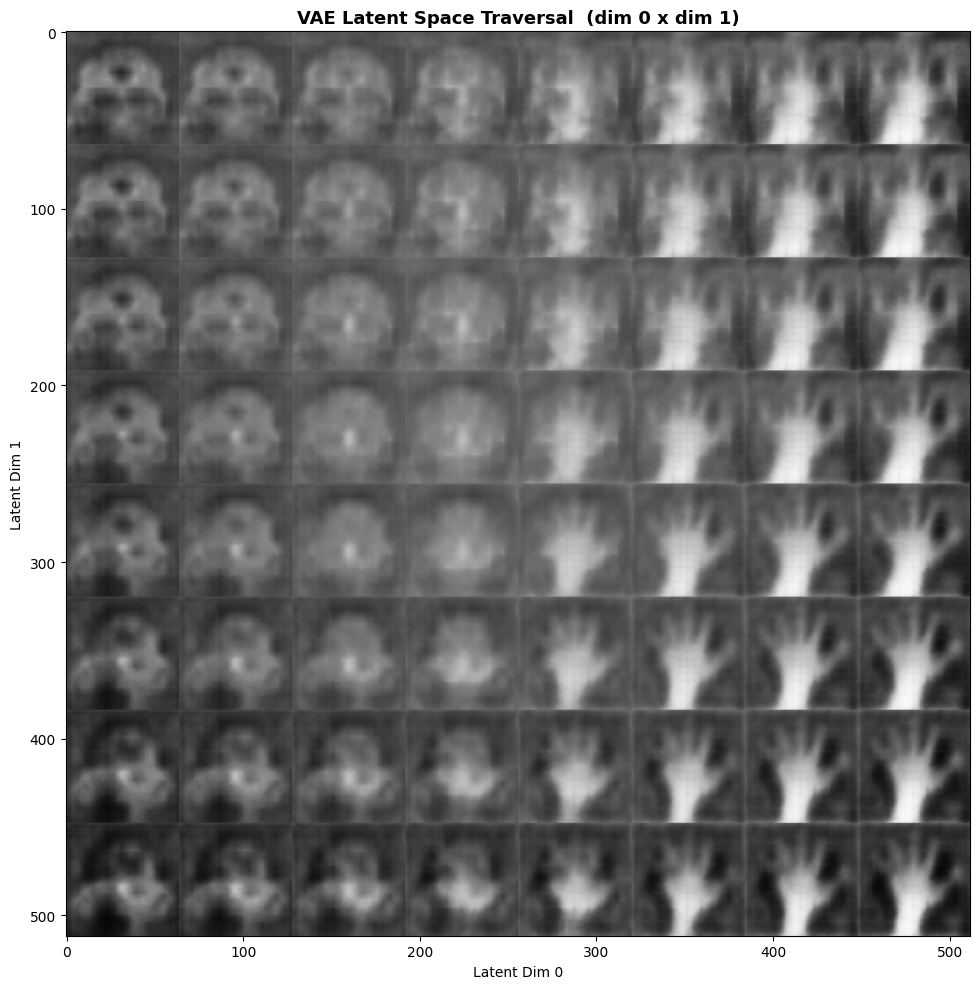

In [23]:
grid_n  = 8
z_range = 2.5
grid_v  = np.linspace(-z_range, z_range, grid_n)
h, w    = IMG_SIZE
canvas  = np.zeros((h * grid_n, w * grid_n))

for r, yv in enumerate(grid_v[::-1]):
    for c, xv in enumerate(grid_v):
        z          = np.zeros((1, LATENT_DIM), dtype='float32')
        z[0, 0]    = xv
        z[0, 1]    = yv
        out        = vae.decoder(z, training=False).numpy()
        canvas[r*h:(r+1)*h, c*w:(c+1)*w] = out[0, :, :, 0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(canvas, cmap='gray', vmin=0, vmax=1)
ax.set_title('VAE Latent Space Traversal  (dim 0 x dim 1)', fontsize=13, fontweight='bold')
ax.set_xlabel('Latent Dim 0'); ax.set_ylabel('Latent Dim 1')
plt.tight_layout()
plt.show()

## 19. Latent Interpolation — AE vs VAE

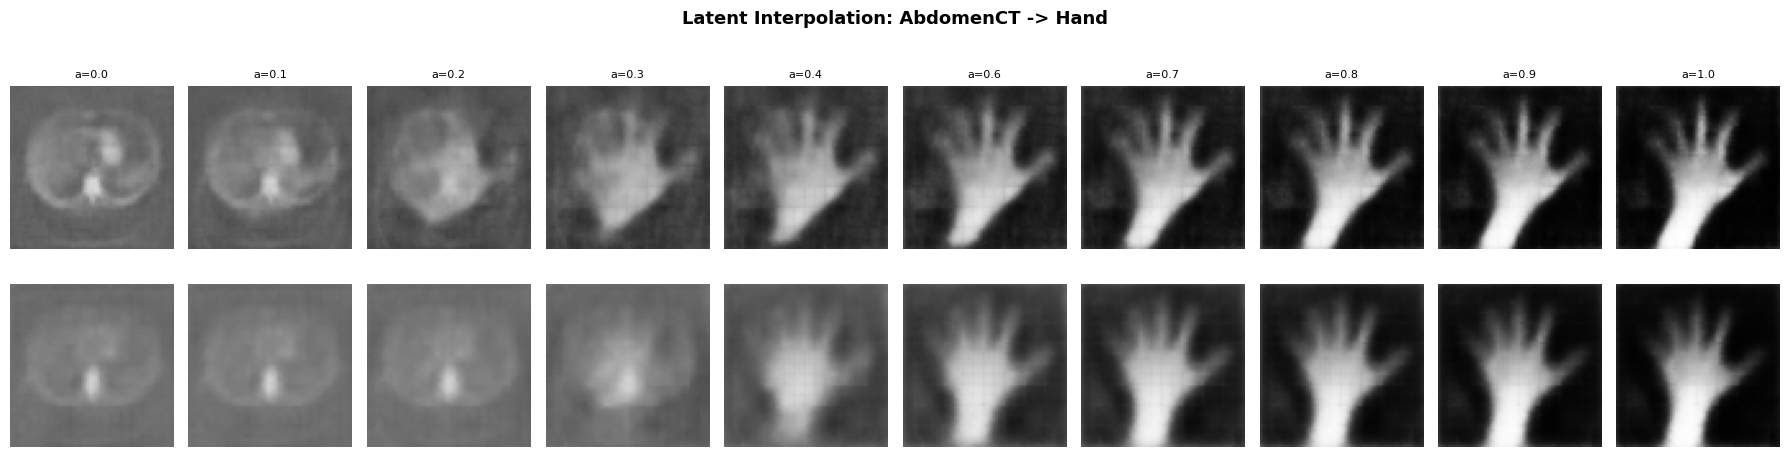

In [24]:
steps = 10
img_a = X[y == 0][0]
img_b = X[y == 4][0]

fig, axes = plt.subplots(2, steps, figsize=(18, 5))
fig.suptitle('Latent Interpolation: AbdomenCT -> Hand', fontsize=13, fontweight='bold')

for row, (model, lbl) in enumerate([(ae, 'AE'), (vae, 'VAE')]):
    za = model.encode(img_a[np.newaxis]).numpy()
    zb = model.encode(img_b[np.newaxis]).numpy()
    for col, alpha in enumerate(np.linspace(0, 1, steps)):
        z   = (1 - alpha) * za + alpha * zb
        out = model.decoder(z, training=False).numpy()
        axes[row, col].imshow(out[0].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(lbl, fontsize=11, fontweight='bold')
        if row == 0:
            axes[row, col].set_title(f'a={alpha:.1f}', fontsize=8)

plt.tight_layout()
plt.show()

## 20. AE vs VAE — Final Comparison

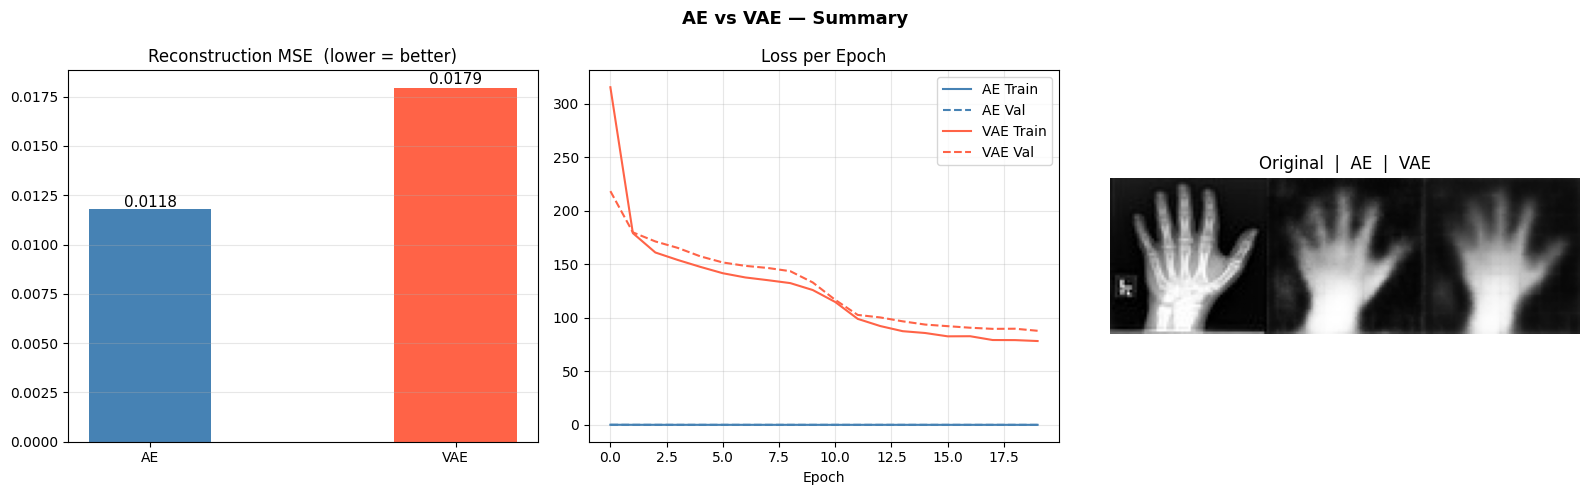

AE  MSE : 0.01179
VAE MSE : 0.01794

AE  -> sharper reconstructions, lower MSE
VAE -> smoother latent space, can generate new images


In [25]:
ae_mse  = float(np.mean((X_val - ae(X_val,  training=False).numpy()) ** 2))
vae_mse = float(np.mean((X_val - vae(X_val, training=False).numpy()) ** 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('AE vs VAE — Summary', fontsize=13, fontweight='bold')

axes[0].bar(['AE', 'VAE'], [ae_mse, vae_mse], color=['steelblue', 'tomato'], width=0.4)
axes[0].set_title('Reconstruction MSE  (lower = better)')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(axes[0].patches, [ae_mse, vae_mse]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{val:.4f}', ha='center', fontsize=11)

axes[1].plot(ae_history.history['loss'],      label='AE Train',  color='steelblue')
axes[1].plot(ae_history.history['val_loss'],  label='AE Val',    color='steelblue', ls='--')
axes[1].plot(vae_history.history['loss'],     label='VAE Train', color='tomato')
axes[1].plot(vae_history.history['val_loss'], label='VAE Val',   color='tomato',    ls='--')
axes[1].set_title('Loss per Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Epoch')

sample = X_val[3:4]
row    = np.concatenate([
    sample[0].squeeze(),
    ae(sample,  training=False).numpy()[0].squeeze(),
    vae(sample, training=False).numpy()[0].squeeze()
], axis=1)
axes[2].imshow(row, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Original  |  AE  |  VAE'); axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'AE  MSE : {ae_mse:.5f}')
print(f'VAE MSE : {vae_mse:.5f}')
print()
print('AE  -> sharper reconstructions, lower MSE')
print('VAE -> smoother latent space, can generate new images')